### Import librairies

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme()
# Show large numbers as 1_000_000; small ones (deltas, prices) keep 4 significant digits
pd.set_option("display.float_format", lambda x: f"{x:_.0f}" if abs(x) >= 1_000 else f"{x:.4g}")

### Custom functions

In [2]:
# --- Monte Carlo simulation ---
def simulate_sabr_paths(F0, T, alpha, beta, rho, nu, n_steps, n_paths, seed=None):
    """Simulate SABR forward and vol paths: dF = sigma * F^beta * dW, dsigma = nu * sigma * dZ, d<W, Z> = rho dt.

    The vol is simulated exactly (lognormal) and the forward with a log-Euler step, which keeps F > 0.
    Returns (F_paths, sigma_paths) as DataFrames indexed by time (years), one column per path.
    """
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    dW = rng.standard_normal((n_steps, n_paths)) * np.sqrt(dt)
    dZ = rho * dW + np.sqrt(1 - rho ** 2) * rng.standard_normal((n_steps, n_paths)) * np.sqrt(dt)

    F = np.empty((n_steps + 1, n_paths))
    sigma = np.empty((n_steps + 1, n_paths))
    F[0], sigma[0] = F0, alpha
    for i in range(n_steps):
        local_vol = sigma[i] * F[i] ** (beta - 1)       # lognormal vol of F over the step
        F[i + 1] = F[i] * np.exp(local_vol * dW[i] - 0.5 * local_vol ** 2 * dt)
        sigma[i + 1] = sigma[i] * np.exp(nu * dZ[i] - 0.5 * nu ** 2 * dt)

    times = np.linspace(0, T, n_steps + 1)
    return pd.DataFrame(F, index=times), pd.DataFrame(sigma, index=times)

### Inputs

In [3]:
# Market parameters
F0 = 100.0                                  # forward (spot = forward, no carry)
T = 252 / 252                               # horizon (years)

# SABR parameters
alpha = 0.20                                # initial vol level (~ ATM lognormal vol when beta = 1)
beta = 1.0                                  # CEV exponent: 1 = lognormal, 0 = normal
rho = -0.90                                 # spot / vol correlation (equity skew)
nu = 0.80                                   # vol of vol

# Simulation parameters
n_steps = 252                               # one step per business day
n_paths = 10_000
seed = 42

### Monte Carlo simulation

In [4]:
F_paths, sigma_paths = simulate_sabr_paths(F0, T, alpha, beta, rho, nu, n_steps, n_paths, seed=seed)

# Sanity checks: F and sigma are martingales, and the correlation of the spot and vol shocks should match rho
log_returns = np.log(F_paths).diff().iloc[1:]
realized_vol = log_returns.std() * np.sqrt(n_steps / T)
vol_returns = np.log(sigma_paths).diff().iloc[1:]
local_vol = (sigma_paths * F_paths ** (beta - 1)).shift().iloc[1:]
spot_shocks = log_returns / local_vol       # returns scaled by the vol at the start of the step
checks = pd.Series({
    "E[F_T]": F_paths.iloc[-1].mean(),
    "E[F_T] std error": F_paths.iloc[-1].std() / np.sqrt(n_paths),
    "E[sigma_T]": sigma_paths.iloc[-1].mean(),
    "mean realized vol": realized_vol.mean(),
    "spot / vol correlation": np.corrcoef(spot_shocks.values.ravel(), vol_returns.values.ravel())[0, 1],
})
display(checks.to_frame("value"))

,value
E[F_T],100.1
E[F_T] std error,0.2002
E[sigma_T],0.2002
mean realized vol,0.2097
spot / vol correlation,-0.9


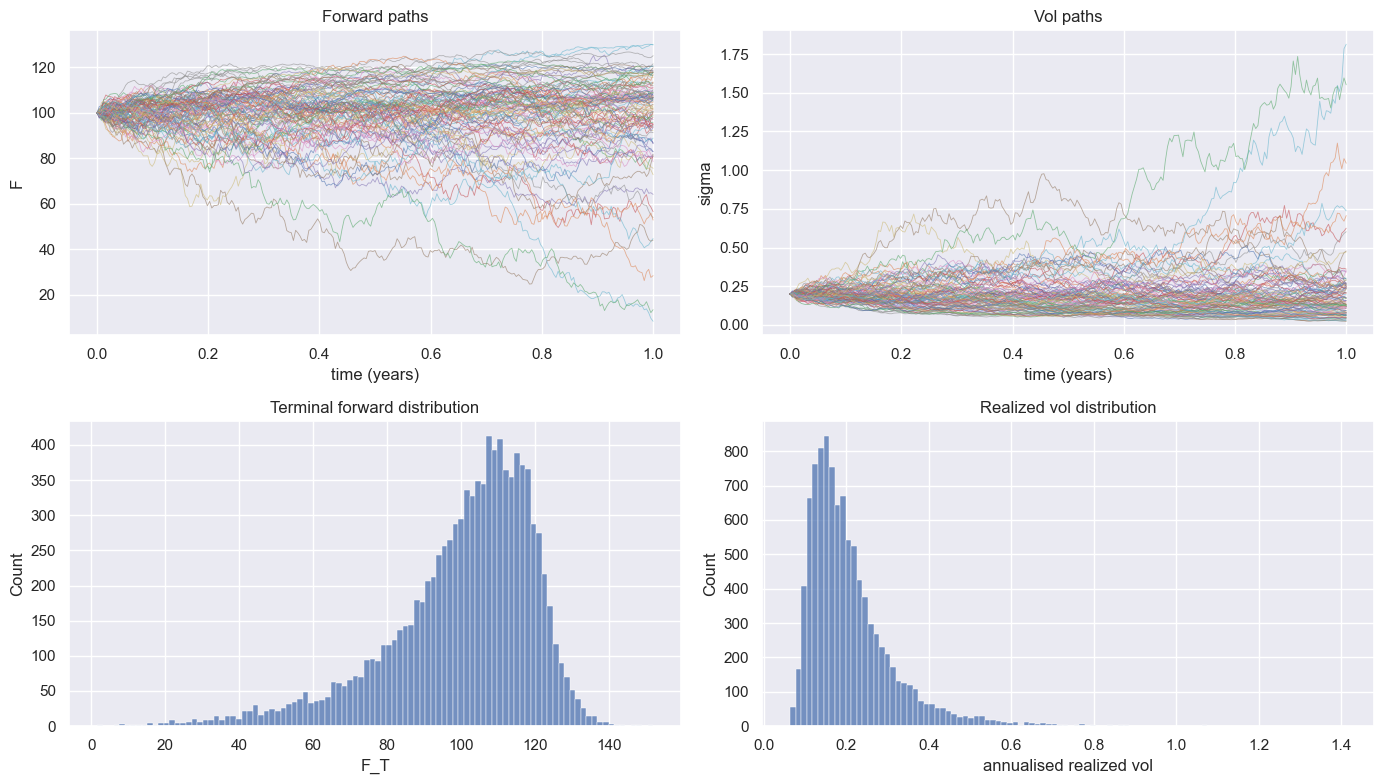

In [5]:
n_plot = 100                                # paths shown on the charts
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

F_paths.iloc[:, :n_plot].plot(ax=axes[0, 0], legend=False, lw=0.6, alpha=0.6)
axes[0, 0].set(title="Forward paths", xlabel="time (years)", ylabel="F")

sigma_paths.iloc[:, :n_plot].plot(ax=axes[0, 1], legend=False, lw=0.6, alpha=0.6)
axes[0, 1].set(title="Vol paths", xlabel="time (years)", ylabel="sigma")

sns.histplot(F_paths.iloc[-1], bins=100, ax=axes[1, 0])
axes[1, 0].set(title="Terminal forward distribution", xlabel="F_T")

sns.histplot(realized_vol, bins=100, ax=axes[1, 1])
axes[1, 1].set(title="Realized vol distribution", xlabel="annualised realized vol")

plt.tight_layout()
plt.show()